# 📉 RetailPulse - Notebook 06
# Customer Churn Prediction

## Objective

Predict customers who are likely to stop purchasing based on their historical behavior.

## Business Value

Customer retention is more cost-effective than customer acquisition. This model helps identify at-risk customers so businesses can take proactive actions such as targeted promotions, personalized offers, and loyalty campaigns.

## Input

- data/processed/customer_features.csv

## Output

- models/churn_prediction_model.pkl
- reports/churn_model_metrics.csv
- reports/high_risk_customers.csv

In [52]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [53]:
# ============================================================
# Project Paths
# ============================================================

BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORT_DIR = BASE_DIR / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

MODEL_DIR = BASE_DIR / "models"

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Project directories are ready.")

Project directories are ready.


In [54]:
# ============================================================
# Load Customer Features
# ============================================================

customer_file = PROCESSED_DIR / "customer_features.csv"

customer_df = pd.read_csv(
    customer_file,
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print("=" * 60)
print("Customer Feature Dataset Loaded")
print("=" * 60)

print("Shape :", customer_df.shape)

display(customer_df.head())

Customer Feature Dataset Loaded
Shape : (5878, 14)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,UniqueCountries,FirstPurchase,LastPurchase,CustomerLifetimeDays,ActiveMonths,RevenuePerMonth,AvgQuantityPerOrder
0,12346.0,326,12,77556.46,74285,2281.072353,27,1,2009-12-14 08:34:00,2011-01-18 10:01:00,400,13.3,5831.31,6190.42
1,12347.0,2,8,4921.53,2967,22.169054,126,1,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.4,367.28,370.88
2,12348.0,75,5,2019.40,2714,39.596078,25,1,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.1,166.89,542.80
3,12349.0,19,4,4428.69,1624,25.306800,138,1,2010-04-29 13:20:00,2011-11-21 09:51:00,570,19.0,233.09,406.00
4,12350.0,310,1,334.40,197,19.670588,17,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.0,334.40,197.00


In [55]:
# ============================================================
# Create Churn Label
# ============================================================

# Customers with Recency > 90 days are considered churned
CHURN_THRESHOLD = 90

customer_df["Churn"] = np.where(
    customer_df["Recency"] > CHURN_THRESHOLD,
    1,
    0
)

print("=" * 60)
print("Churn Label Created Successfully")
print("=" * 60)

customer_df["Churn"].value_counts()

Churn Label Created Successfully


Churn
1    2989
0    2889
Name: count, dtype: int64

Churn
1    2989
0    2889
Name: count, dtype: int64


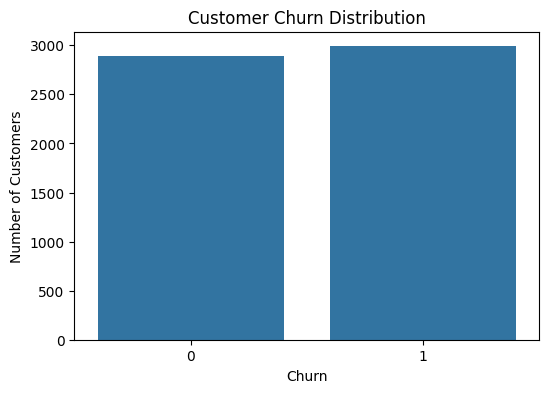

In [56]:
# ============================================================
# Churn Distribution
# ============================================================

churn_counts = customer_df["Churn"].value_counts()

print(churn_counts)

plt.figure(figsize=(6,4))

sns.countplot(
    data=customer_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [57]:
# ============================================================
# Churn Percentage
# ============================================================

churn_percentage = (
    customer_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
1    50.85
0    49.15
Name: proportion, dtype: float64


In [58]:
# ============================================================
# Feature Selection
# ============================================================

feature_columns = [
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue",
    "UniqueProducts",
    "UniqueCountries",
    "CustomerLifetimeDays",
    "ActiveMonths",
    "RevenuePerMonth",
    "AvgQuantityPerOrder"
]

X = customer_df[feature_columns]

y = customer_df["Churn"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (5878, 10)
Target Shape : (5878,)


In [59]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print("=" * 60)

Training Set : (4702, 10)
Testing Set  : (1176, 10)


In [60]:
# ============================================================
# Model Comparison
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.736395,0.720183,0.787625,0.752396
0,Logistic Regression,0.719388,0.703647,0.774247,0.737261
3,XGBoost,0.718537,0.710900,0.752508,0.731113
1,Decision Tree,0.663265,0.679715,0.638796,0.658621


In [61]:
# ============================================================
# Final Model for Deployment
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Final Random Forest model trained successfully.")

Final Random Forest model trained successfully.


In [62]:
model_path = MODEL_DIR / "customer_churn_model.pkl"

joblib.dump(rf_model, model_path)

['c:\\N_VsCode\\Zidio Project\\PROJECT\\RetailPulse-AI-Customer-Analytics\\models\\customer_churn_model.pkl']

In [63]:
# ============================================================
# Export High-Risk Customers
# ============================================================

customer_df["PredictedChurn"] = rf_model.predict(X)

high_risk_customers = customer_df[
    customer_df["PredictedChurn"] == 1
].copy()

output_file = REPORT_DIR / "high_risk_customers.csv"

high_risk_customers.to_csv(
    output_file,
    index=False
)

print("=" * 60)
print("High-Risk Customer Export Completed")
print("=" * 60)
print(f"Total Customers        : {len(customer_df)}")
print(f"High-Risk Customers    : {len(high_risk_customers)}")
print(f"Export Location        : {output_file}")

High-Risk Customer Export Completed
Total Customers        : 5878
High-Risk Customers    : 3414
Export Location        : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\high_risk_customers.csv


In [64]:
# ============================================================
# Business Insights
# ============================================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

total_customers = len(customer_df)

actual_churn = customer_df["Churn"].sum()
actual_rate = actual_churn / total_customers * 100

predicted_churn = customer_df["PredictedChurn"].sum()
predicted_rate = predicted_churn / total_customers * 100

print(f"Total Customers              : {total_customers}")
print(f"Actual Churn Customers       : {actual_churn}")
print(f"Predicted High-Risk Customers: {predicted_churn}")

print(f"\nActual Churn Rate            : {actual_rate:.2f}%")
print(f"Predicted Churn Rate         : {predicted_rate:.2f}%")

print("\nTop 5 Features Influencing Churn:")
print("-" * 45)

top_features = feature_importance.head().copy()
top_features["Importance (%)"] = top_features["Importance"] * 100

print(
    top_features[["Feature", "Importance (%)"]]
    .to_string(index=False, formatters={"Importance (%)": "{:.2f}%".format})
)

print("\nBusiness Recommendations:")
print("- Focus retention campaigns on predicted high-risk customers.")
print("- Increase engagement for customers with long inactivity periods.")
print("- Reward loyal customers with personalized offers.")
print("- Monitor customer lifetime value and purchase frequency.")
print("- Retrain the churn model periodically using new customer transaction data.")

print("\nNotebook 06 completed successfully.")

BUSINESS INSIGHTS
Total Customers              : 5878
Actual Churn Customers       : 2989
Predicted High-Risk Customers: 3414

Actual Churn Rate            : 50.85%
Predicted Churn Rate         : 58.08%

Top 5 Features Influencing Churn:
---------------------------------------------
             Feature Importance (%)
CustomerLifetimeDays         22.05%
        ActiveMonths         17.29%
       TotalQuantity         12.69%
            Monetary          9.32%
           Frequency          8.94%

Business Recommendations:
- Focus retention campaigns on predicted high-risk customers.
- Increase engagement for customers with long inactivity periods.
- Reward loyal customers with personalized offers.
- Monitor customer lifetime value and purchase frequency.
- Retrain the churn model periodically using new customer transaction data.

Notebook 06 completed successfully.


In [65]:
print(customer_df["Churn"].value_counts())

print(customer_df["Churn"].value_counts(normalize=True) * 100)

Churn
1    2989
0    2889
Name: count, dtype: int64
Churn
1    50.850629
0    49.149371
Name: proportion, dtype: float64
